In [ ]:
# ============================================================
# CELL 1: ENVIRONMENT & IMPORTS
# ============================================================

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("PyTorch version:", torch.__version__)
print("Torchvision version:", __import__("torchvision").__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

PyTorch version: 2.11.0+cu128
Torchvision version: 0.26.0+cu128
Device: cuda


In [ ]:
# ============================================================
# CELL 2: REPRODUCIBILITY
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# Make CUDA operations deterministic where possible
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Random seed set to: {SEED}")

Random seed set to: 42


In [ ]:
# Download Dataset

!pip -q install kagglehub
import kagglehub

# Download the latest version of the dataset
dataset_path = kagglehub.dataset_download(
    "ajg117/indian-paintings-dataset"
)

print("Dataset path:")
print(dataset_path)

100%|██████████| 355M/355M [00:17<00:00, 21.4MB/s]

Extracting files...


Dataset path:
/root/.cache/kagglehub/datasets/ajg117/indian-paintings-dataset/versions/3


In [ ]:
# ============================================================
# CELL 4: LOAD DATASET & INITIAL INSPECTION
# ============================================================

# Load dataset without transforms.
# Transforms will be applied later through TransformSubset.
base_dataset = datasets.ImageFolder(
    root=dataset_path,
    transform=None
)

class_names = base_dataset.classes
NUM_CLASSES = len(class_names)

print("Dataset root:", dataset_path)
print("Number of images:", len(base_dataset))
print("Number of classes:", NUM_CLASSES)

print("\nClasses:")
for idx, class_name in enumerate(class_names):
    print(f"{idx}: {class_name}")

# Class distribution
class_counts = np.bincount(base_dataset.targets)

print("\nClass distribution:")
for idx, count in enumerate(class_counts):
    print(f"{class_names[idx]}: {count}")

Dataset root: /root/.cache/kagglehub/datasets/ajg117/indian-paintings-dataset/versions/3
Number of images: 953
Number of classes: 8

Classes:
0: gond painting
1: kalighat painting
2: kangra painting
3: kerala mural
4: madhubani painting
5: mandana art drawing
6: pichwai painting
7: warli painting

Class distribution:
gond painting: 98
kalighat painting: 246
kangra painting: 87
kerala mural: 94
madhubani painting: 95
mandana art drawing: 140
pichwai painting: 96
warli painting: 97


In [ ]:
# ============================================================
# CELL 5: TRAIN / VALIDATION / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

# All dataset indices
indices = np.arange(len(base_dataset))
targets = np.array(base_dataset.targets)

# ------------------------------------------------------------
# First split: 70% Train, 30% Temporary
# ------------------------------------------------------------
train_indices, temp_indices = train_test_split(
    indices,
    test_size=0.30,
    stratify=targets,
    random_state=SEED
)

# ------------------------------------------------------------
# Second split: Temporary → 15% Validation, 15% Test
# ------------------------------------------------------------
temp_targets = targets[temp_indices]

val_indices, test_indices = train_test_split(
    temp_indices,
    test_size=0.50,
    stratify=temp_targets,
    random_state=SEED
)

print("Dataset split:")
print(f"Train      : {len(train_indices)} images")
print(f"Validation : {len(val_indices)} images")
print(f"Test       : {len(test_indices)} images")

print("\nPercentages:")
print(f"Train      : {len(train_indices) / len(base_dataset) * 100:.2f}%")
print(f"Validation : {len(val_indices) / len(base_dataset) * 100:.2f}%")
print(f"Test       : {len(test_indices) / len(base_dataset) * 100:.2f}%")

Dataset split:
Train      : 667 images
Validation : 143 images
Test       : 143 images

Percentages:
Train      : 69.99%
Validation : 15.01%
Test       : 15.01%


In [ ]:
# ============================================================
# CELL 6: IMAGE TRANSFORMS
# ============================================================

IMG_SIZE = 224

# Training transformations
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Validation / Test transformations
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Image size:", IMG_SIZE)
print("Training and evaluation transforms created successfully.")

Image size: 224
Training and evaluation transforms created successfully.


In [ ]:
# ============================================================
# CELL 7: TRANSFORM SUBSET
# ============================================================

class TransformSubset(torch.utils.data.Dataset):
    """
    Subset wrapper that applies a specific transform
    to images while preserving the original dataset split.
    """

    def __init__(self, dataset, indices, transform=None):
        self.dataset = dataset
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        original_idx = self.indices[idx]

        image, label = self.dataset[original_idx]

        if self.transform:
            image = self.transform(image)

        return image, label


# Create transformed subsets
train_dataset = TransformSubset(
    base_dataset,
    train_indices,
    transform=train_transform
)

val_dataset = TransformSubset(
    base_dataset,
    val_indices,
    transform=eval_transform
)

test_dataset = TransformSubset(
    base_dataset,
    test_indices,
    transform=eval_transform
)

print("Transformed subsets created successfully.")
print(f"Train dataset      : {len(train_dataset)}")
print(f"Validation dataset : {len(val_dataset)}")
print(f"Test dataset       : {len(test_dataset)}")

Transformed subsets created successfully.
Train dataset      : 667
Validation dataset : 143
Test dataset       : 143


In [ ]:
# ============================================================
# CELL 8: DATALOADERS
# ============================================================

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("DataLoaders created successfully.")
print(f"Batch size: {BATCH_SIZE}")

print("\nNumber of batches:")
print(f"Train      : {len(train_loader)}")
print(f"Validation : {len(val_loader)}")
print(f"Test       : {len(test_loader)}")

DataLoaders created successfully.
Batch size: 32

Number of batches:
Train      : 21
Validation : 5
Test       : 5


In [ ]:
# ============================================================
# CELL 9: VERIFY BATCH
# ============================================================

images, labels = next(iter(train_loader))

print("Batch verification")
print("-" * 40)
print("Image tensor shape :", images.shape)
print("Label tensor shape :", labels.shape)
print("Image dtype        :", images.dtype)
print("Label dtype        :", labels.dtype)
print("Image min          :", images.min().item())
print("Image max          :", images.max().item())
print("Labels             :", labels[:10].tolist())

Batch verification
----------------------------------------
Image tensor shape : torch.Size([32, 3, 224, 224])
Label tensor shape : torch.Size([32])
Image dtype        : torch.float32
Label dtype        : torch.int64
Image min          : -2.1179039478302
Image max          : 2.640000104904175
Labels             : [3, 6, 7, 2, 5, 5, 5, 3, 4, 1]


In [ ]:
# ============================================================
# CELL 10: LOAD PRETRAINED SWIN TRANSFORMER
# ============================================================

# Load pretrained Swin-Tiny
weights = models.Swin_T_Weights.DEFAULT

model = models.swin_t(weights=weights)

print(model)

Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to /root/.cache/torch/hub/checkpoints/swin_t-704ceda3.pth


100%|██████████| 108M/108M [00:00<00:00, 116MB/s] 


SwinTransformer(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): Permute()
      (2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
    )
    (1): Sequential(
      (0): SwinTransformerBlock(
        (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (attn): ShiftedWindowAttention(
          (qkv): Linear(in_features=96, out_features=288, bias=True)
          (proj): Linear(in_features=96, out_features=96, bias=True)
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (0): Linear(in_features=96, out_features=384, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=384, out_features=96, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (1): SwinTransformerBlock(
       

In [ ]:
# ============================================================
# CELL 11: REPLACE CLASSIFICATION HEAD
# ============================================================

# Get the number of input features to the existing classifier
in_features = model.head.in_features

# Replace ImageNet classification head with our dataset-specific head
model.head = nn.Linear(
    in_features=in_features,
    out_features=NUM_CLASSES
)

# Move model to GPU
model = model.to(device)

print("Swin classification head replaced successfully.")
print("Input features :", in_features)
print("Output classes  :", NUM_CLASSES)
print("Device          :", device)
print("\nNew classification head:")
print(model.head)

Swin classification head replaced successfully.
Input features : 768
Output classes  : 8
Device          : cuda

New classification head:
Linear(in_features=768, out_features=8, bias=True)


In [ ]:
# ============================================================
# CELL 12: STAGE 1 — FREEZE SWIN BACKBONE
# ============================================================

# Freeze all Swin parameters
for param in model.features.parameters():
    param.requires_grad = False

# Keep the classification head trainable
for param in model.head.parameters():
    param.requires_grad = True

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

print("Stage 1 — Frozen Swin Backbone")
print("-" * 45)
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")
print(f"Frozen parameters    : {total_params - trainable_params:,}")

print("\nTrainable layers:")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

Stage 1 — Frozen Swin Backbone
---------------------------------------------
Total parameters     : 27,525,506
Trainable parameters : 7,688
Frozen parameters    : 27,517,818

Trainable layers:
norm.weight
norm.bias
head.weight
head.bias


In [ ]:
# ============================================================
# CELL 13: STAGE 1 — LOSS FUNCTION & OPTIMIZER
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
    weight_decay=1e-4
)

print("Stage 1 training configuration")
print("-" * 45)
print("Loss function :", criterion)
print("Optimizer     :", optimizer.__class__.__name__)
print("Learning rate :", 1e-3)
print("Weight decay  :", 1e-4)

Stage 1 training configuration
---------------------------------------------
Loss function : CrossEntropyLoss()
Optimizer     : AdamW
Learning rate : 0.001
Weight decay  : 0.0001


In [ ]:
# ============================================================
# CELL 14: TRAINING & VALIDATION FUNCTIONS
# ============================================================

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy


def validate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy


print("Training and validation functions defined successfully.")

Training and validation functions defined successfully.


In [ ]:
# ============================================================
# CELL 15: STAGE 1 — TRAIN FROZEN SWIN BACKBONE
# ============================================================

NUM_EPOCHS_STAGE1 = 10

stage1_history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_val_acc_stage1 = 0.0
best_state_stage1 = None

print("=" * 70)
print("STAGE 1 — FROZEN SWIN BACKBONE")
print("=" * 70)

for epoch in range(NUM_EPOCHS_STAGE1):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        device
    )

    # Store history
    stage1_history["train_loss"].append(train_loss)
    stage1_history["train_acc"].append(train_acc)
    stage1_history["val_loss"].append(val_loss)
    stage1_history["val_acc"].append(val_acc)

    # Keep best validation model in memory
    if val_acc > best_val_acc_stage1:
        best_val_acc_stage1 = val_acc
        best_state_stage1 = {
            key: value.cpu().clone()
            for key, value in model.state_dict().items()
        }

    print(
        f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS_STAGE1}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

print("\nStage 1 complete.")
print(f"Best Stage 1 validation accuracy: {best_val_acc_stage1:.4f}")

STAGE 1 — FROZEN SWIN BACKBONE


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [01/10] | Train Loss: 1.6678 | Train Acc: 0.3778 | Val Loss: 1.1951 | Val Acc: 0.6503


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [02/10] | Train Loss: 1.0562 | Train Acc: 0.7256 | Val Loss: 0.8452 | Val Acc: 0.7483


...

Epoch [08/10] | Train Loss: 0.4453 | Train Acc: 0.8876 | Val Loss: 0.4672 | Val Acc: 0.8741


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [09/10] | Train Loss: 0.3955 | Train Acc: 0.9040 | Val Loss: 0.4537 | Val Acc: 0.8811


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [10/10] | Train Loss: 0.3725 | Train Acc: 0.9055 | Val Loss: 0.4434 | Val Acc: 0.8811

Stage 1 complete.
Best Stage 1 validation accuracy: 0.8811


In [ ]:
# ============================================================
# CELL 16: RESTORE BEST STAGE 1 CHECKPOINT
# ============================================================

if best_state_stage1 is None:
    raise RuntimeError("No best Stage 1 checkpoint was saved.")

# Restore best validation checkpoint
model.load_state_dict(best_state_stage1)

# Move model back to the selected device
model = model.to(device)

print("Best Stage 1 checkpoint restored successfully.")
print(f"Best Stage 1 validation accuracy: {best_val_acc_stage1:.4f}")

Best Stage 1 checkpoint restored successfully.
Best Stage 1 validation accuracy: 0.8811


In [ ]:
# ============================================================
# CELL 17: STAGE 2 — UNFREEZE FINAL SWIN STAGE
# ============================================================

# Freeze the entire Swin backbone first
for param in model.features.parameters():
    param.requires_grad = False

# Unfreeze the final Swin stage
for param in model.features[7].parameters():
    param.requires_grad = True

# Keep classification head trainable
for param in model.head.parameters():
    param.requires_grad = True

# Count parameters
total_params = sum(p.numel() for p in model.parameters())

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

frozen_params = total_params - trainable_params

print("=" * 60)
print("STAGE 2 — SWIN FINE-TUNING")
print("=" * 60)

print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")
print(f"Frozen parameters    : {frozen_params:,}")

print("\nTrainable parameter groups:")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

STAGE 2 — SWIN FINE-TUNING
Total parameters     : 27,525,506
Trainable parameters : 14,191,544
Frozen parameters    : 13,333,962

Trainable parameter groups:
features.7.0.norm1.weight
features.7.0.norm1.bias
features.7.0.attn.relative_position_bias_table
features.7.0.attn.qkv.weight
features.7.0.attn.qkv.bias
features.7.0.attn.proj.weight
features.7.0.attn.proj.bias
features.7.0.norm2.weight
features.7.0.norm2.bias
features.7.0.mlp.0.weight
features.7.0.mlp.0.bias
features.7.0.mlp.3.weight
features.7.0.mlp.3.bias
features.7.1.norm1.weight
features.7.1.norm1.bias
features.7.1.attn.relative_position_bias_table
features.7.1.attn.qkv.weight
features.7.1.attn.qkv.bias
features.7.1.attn.proj.weight
features.7.1.attn.proj.bias
features.7.1.norm2.weight
features.7.1.norm2.bias
features.7.1.mlp.0.weight
features.7.1.mlp.0.bias
features.7.1.mlp.3.weight
features.7.1.mlp.3.bias
norm.weight
norm.bias
head.weight
head.bias


In [ ]:
# ============================================================
# CELL 18: STAGE 2 — LOSS FUNCTION & OPTIMIZER
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5,
    weight_decay=1e-4
)

print("Stage 2 training configuration")
print("-" * 45)
print("Loss function :", criterion)
print("Optimizer     :", optimizer.__class__.__name__)
print("Learning rate :", 1e-5)
print("Weight decay  :", 1e-4)
print("Trainable parameters:", sum(
    p.numel() for p in model.parameters() if p.requires_grad
))

Stage 2 training configuration
---------------------------------------------
Loss function : CrossEntropyLoss()
Optimizer     : AdamW
Learning rate : 1e-05
Weight decay  : 0.0001
Trainable parameters: 14191544


In [ ]:
# ============================================================
# CELL 19: STAGE 2 — FINE-TUNING
# ============================================================

NUM_EPOCHS_STAGE2 = 5

stage2_history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_val_acc_stage2 = best_val_acc_stage1
best_state_stage2 = {
    key: value.cpu().clone()
    for key, value in model.state_dict().items()
}

print("=" * 70)
print("STAGE 2 — FINE-TUNING FINAL SWIN STAGE")
print("=" * 70)

for epoch in range(NUM_EPOCHS_STAGE2):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        device
    )

    # Store history
    stage2_history["train_loss"].append(train_loss)
    stage2_history["train_acc"].append(train_acc)
    stage2_history["val_loss"].append(val_loss)
    stage2_history["val_acc"].append(val_acc)

    # Save best model based on validation accuracy
    if val_acc > best_val_acc_stage2:
        best_val_acc_stage2 = val_acc
        best_state_stage2 = {
            key: value.cpu().clone()
            for key, value in model.state_dict().items()
        }

    print(
        f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS_STAGE2}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

print("\nStage 2 complete.")
print(f"Best validation accuracy: {best_val_acc_stage2:.4f}")

STAGE 2 — FINE-TUNING FINAL SWIN STAGE


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [01/5] | Train Loss: 0.3880 | Train Acc: 0.9025 | Val Loss: 0.4256 | Val Acc: 0.8811


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [02/5] | Train Loss: 0.3256 | Train Acc: 0.9145 | Val Loss: 0.4094 | Val Acc: 0.8811


...

Epoch [03/5] | Train Loss: 0.2876 | Train Acc: 0.9295 | Val Loss: 0.3915 | Val Acc: 0.8811


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [04/5] | Train Loss: 0.2521 | Train Acc: 0.9325 | Val Loss: 0.3789 | Val Acc: 0.8881


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [05/5] | Train Loss: 0.2768 | Train Acc: 0.9130 | Val Loss: 0.3701 | Val Acc: 0.8811

Stage 2 complete.
Best validation accuracy: 0.8881


In [ ]:
# ============================================================
# CELL 20: RESTORE BEST STAGE 2 CHECKPOINT
# ============================================================

if best_state_stage2 is None:
    raise RuntimeError("No best Stage 2 checkpoint was saved.")

# Restore the best validation checkpoint
model.load_state_dict(best_state_stage2)

# Move model to device
model = model.to(device)

# Set evaluation mode
model.eval()

print("=" * 60)
print("BEST SWIN MODEL RESTORED")
print("=" * 60)
print(f"Best validation accuracy: {best_val_acc_stage2:.4f}")
print("Model ready for test evaluation.")

BEST SWIN MODEL RESTORED
Best validation accuracy: 0.8881
Model ready for test evaluation.


In [ ]:
# ============================================================
# CELL 21: TEST SET PREDICTIONS
# ============================================================

model.eval()

all_labels = []
all_predictions = []
all_probabilities = []

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)

        # Convert logits to probabilities
        probabilities = torch.softmax(outputs, dim=1)

        # Get predicted class
        predictions = torch.argmax(outputs, dim=1)

        # Store results on CPU
        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())
        all_probabilities.extend(probabilities.cpu().numpy())

all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)
all_probabilities = np.array(all_probabilities)

print("=" * 60)
print("TEST SET PREDICTIONS COMPLETE")
print("=" * 60)

print("Number of test samples :", len(all_labels))
print("Predictions shape      :", all_predictions.shape)
print("Probabilities shape    :", all_probabilities.shape)

TEST SET PREDICTIONS COMPLETE
Number of test samples : 143
Predictions shape      : (143,)
Probabilities shape    : (143, 8)


In [ ]:
# ============================================================
# CELL 22: FINAL TEST METRICS
# ============================================================

test_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

test_precision_macro = precision_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

test_recall_macro = recall_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

test_f1_macro = f1_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

test_f1_weighted = f1_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

print("=" * 60)
print("SWIN TRANSFORMER — FINAL TEST METRICS")
print("=" * 60)

print(f"Accuracy          : {test_accuracy:.4f}")
print(f"Macro Precision   : {test_precision_macro:.4f}")
print(f"Macro Recall      : {test_recall_macro:.4f}")
print(f"Macro F1          : {test_f1_macro:.4f}")
print(f"Weighted F1       : {test_f1_weighted:.4f}")

SWIN TRANSFORMER — FINAL TEST METRICS
Accuracy          : 0.8392
Macro Precision   : 0.8397
Macro Recall      : 0.8340
Macro F1          : 0.8350
Weighted F1       : 0.8371


In [ ]:
# ============================================================
# CELL 23: CLASSIFICATION REPORT
# ============================================================

report = classification_report(
    all_labels,
    all_predictions,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print("=" * 80)
print("SWIN TRANSFORMER — CLASSIFICATION REPORT")
print("=" * 80)
print(report)

SWIN TRANSFORMER — CLASSIFICATION REPORT
                     precision    recall  f1-score   support

      gond painting     1.0000    0.9333    0.9655        15
  kalighat painting     0.8250    0.8919    0.8571        37
    kangra painting     0.8571    0.9231    0.8889        13
       kerala mural     0.8750    1.0000    0.9333        14
 madhubani painting     0.6154    0.5714    0.5926        14
mandana art drawing     0.8421    0.7619    0.8000        21
   pichwai painting     0.8462    0.7333    0.7857        15
     warli painting     0.8571    0.8571    0.8571        14

           accuracy                         0.8392       143
          macro avg     0.8397    0.8340    0.8350       143
       weighted avg     0.8385    0.8392    0.8371       143



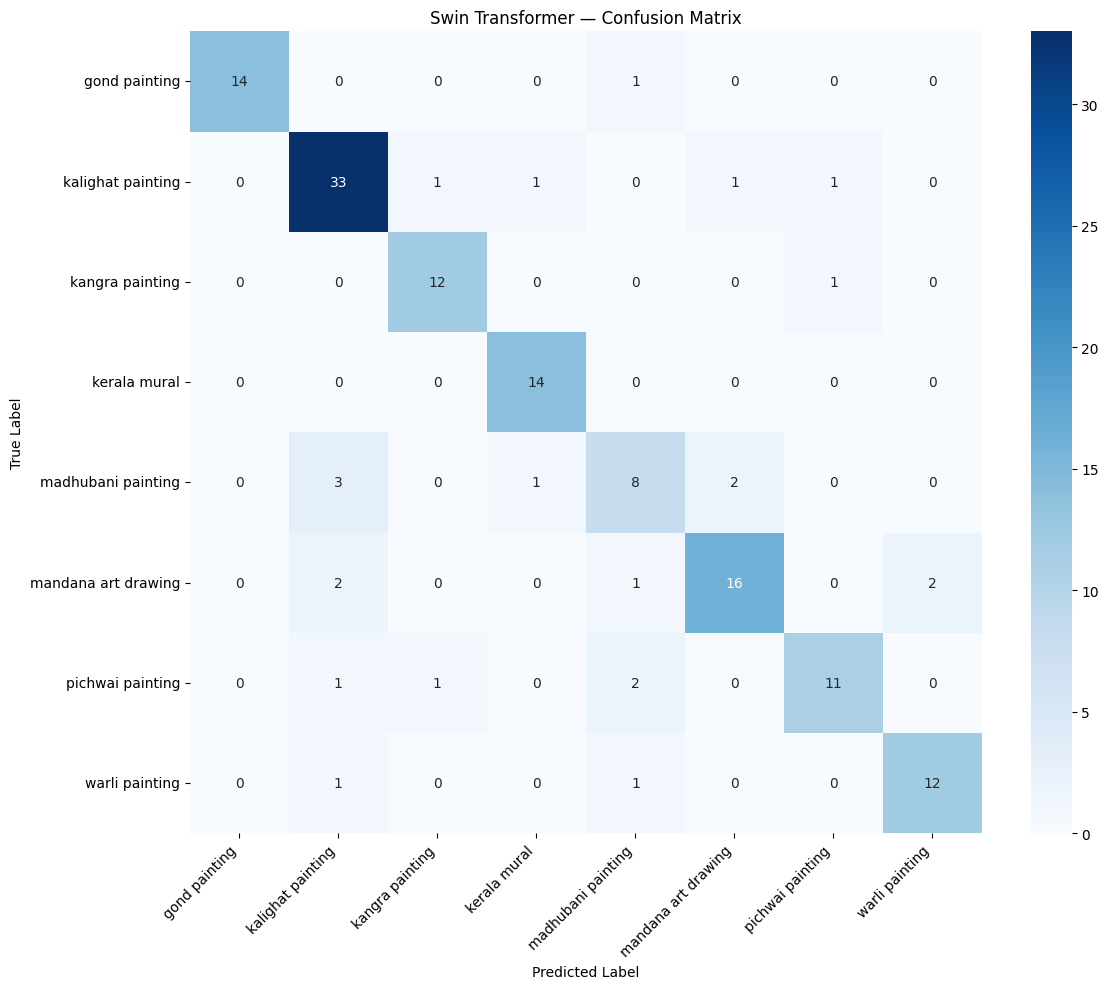

In [ ]:
# ============================================================
# CELL 24: CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Swin Transformer — Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()

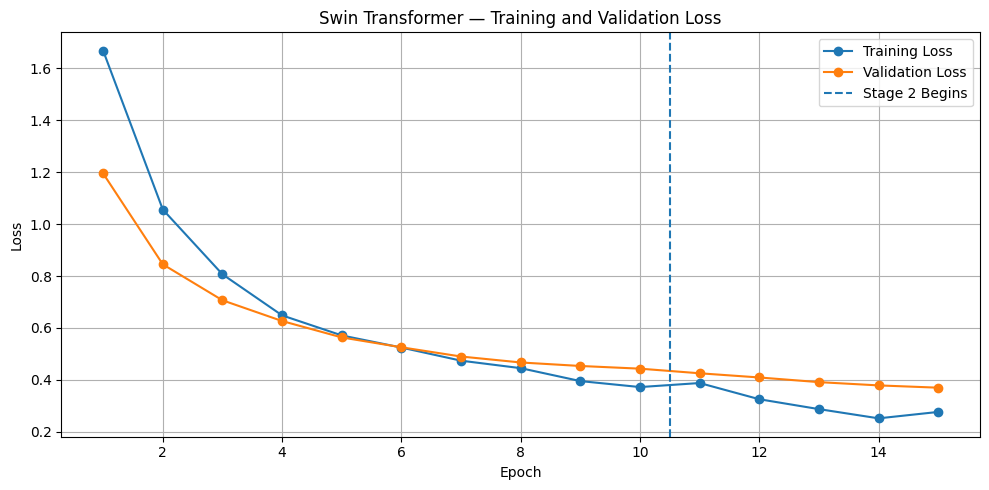

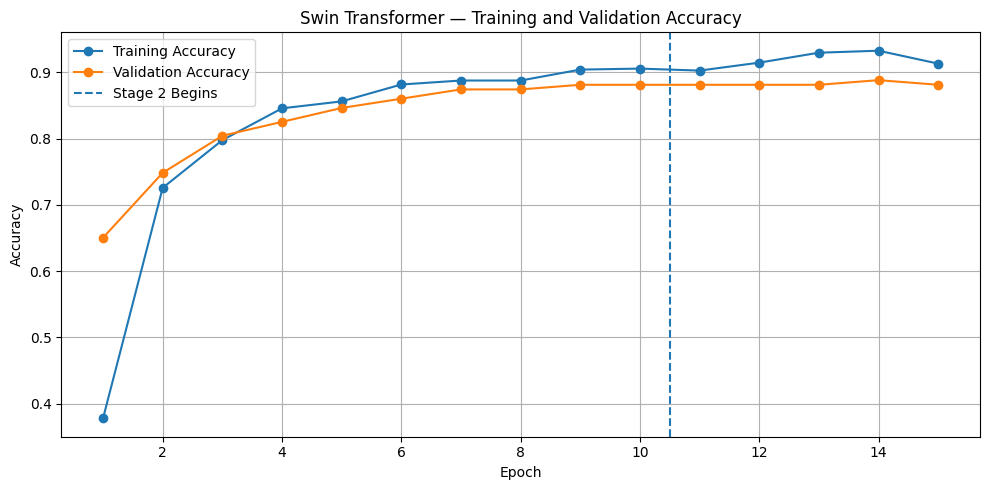

In [ ]:
# ============================================================
# CELL 25: TRAINING & VALIDATION CURVES
# ============================================================

# Combine Stage 1 and Stage 2 histories
train_loss = (
    stage1_history["train_loss"]
    + stage2_history["train_loss"]
)

val_loss = (
    stage1_history["val_loss"]
    + stage2_history["val_loss"]
)

train_acc = (
    stage1_history["train_acc"]
    + stage2_history["train_acc"]
)

val_acc = (
    stage1_history["val_acc"]
    + stage2_history["val_acc"]
)

epochs = range(1, len(train_loss) + 1)

# ------------------------------------------------------------
# Loss Curve
# ------------------------------------------------------------
plt.figure(figsize=(10, 5))

plt.plot(
    epochs,
    train_loss,
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    val_loss,
    marker="o",
    label="Validation Loss"
)

# Mark Stage 2 beginning
plt.axvline(
    x=NUM_EPOCHS_STAGE1 + 0.5,
    linestyle="--",
    label="Stage 2 Begins"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Swin Transformer — Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Accuracy Curve
# ------------------------------------------------------------
plt.figure(figsize=(10, 5))

plt.plot(
    epochs,
    train_acc,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs,
    val_acc,
    marker="o",
    label="Validation Accuracy"
)

# Mark Stage 2 beginning
plt.axvline(
    x=NUM_EPOCHS_STAGE1 + 0.5,
    linestyle="--",
    label="Stage 2 Begins"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Swin Transformer — Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 26: FINAL MODEL SUMMARY
# ============================================================

swin_results = {
    "Model": "Swin-Tiny",
    "Stage 1 Best Val Accuracy": best_val_acc_stage1,
    "Stage 2 Best Val Accuracy": best_val_acc_stage2,
    "Test Accuracy": test_accuracy,
    "Macro Precision": test_precision_macro,
    "Macro Recall": test_recall_macro,
    "Macro F1": test_f1_macro,
    "Weighted F1": test_f1_weighted,
    "Total Parameters": total_params,
    "Trainable Parameters (Stage 2)": trainable_params
}

swin_results_df = pd.DataFrame([swin_results])

print("=" * 80)
print("PIPELINE 4 — SWIN TRANSFORMER FINAL SUMMARY")
print("=" * 80)

display(
    swin_results_df.style.format({
        "Stage 1 Best Val Accuracy": "{:.4f}",
        "Stage 2 Best Val Accuracy": "{:.4f}",
        "Test Accuracy": "{:.4f}",
        "Macro Precision": "{:.4f}",
        "Macro Recall": "{:.4f}",
        "Macro F1": "{:.4f}",
        "Weighted F1": "{:.4f}",
        "Total Parameters": "{:,}",
        "Trainable Parameters (Stage 2)": "{:,}"
    })
)

PIPELINE 4 — SWIN TRANSFORMER FINAL SUMMARY


,Model,Stage 1 Best Val Accuracy,Stage 2 Best Val Accuracy,Test Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Total Parameters,Trainable Parameters (Stage 2)
0,Swin-Tiny,0.8811,0.8881,0.8392,0.8397,0.8340,0.8350,0.8371,"27,525,506","14,191,544"


In [ ]:
# ============================================================
# CELL 27: SAVE BEST SWIN MODEL TO GOOGLE DRIVE
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

# ------------------------------------------------------------
# Set the project folder
# ------------------------------------------------------------
DRIVE_DIR = "/content/drive/MyDrive/Iconography/Implementation/Swin-T"

os.makedirs(DRIVE_DIR, exist_ok=True)

# Best model checkpoint path
BEST_MODEL_PATH = os.path.join(
    DRIVE_DIR,
    "best_swin_tiny.pth"
)

# Save best validation checkpoint
torch.save(
    {
        "model_state_dict": best_state_stage2,
        "class_names": class_names,
        "num_classes": NUM_CLASSES,
        "best_val_accuracy": best_val_acc_stage2,
        "test_accuracy": test_accuracy,
        "macro_precision": test_precision_macro,
        "macro_recall": test_recall_macro,
        "macro_f1": test_f1_macro,
        "weighted_f1": test_f1_weighted,
        "seed": SEED,
        "img_size": IMG_SIZE
    },
    BEST_MODEL_PATH
)

print("=" * 70)
print("BEST SWIN MODEL SAVED")
print("=" * 70)
print("Path:")
print(BEST_MODEL_PATH)

print("\nFile size:")
print(f"{os.path.getsize(BEST_MODEL_PATH) / (1024**2):.2f} MB")

Mounted at /content/drive
BEST SWIN MODEL SAVED
Path:
/content/drive/MyDrive/Iconography/Implementation/Swin-T/best_swin_tiny.pth

File size:
105.28 MB
